# 01 — Customer EDA
## Bank Churners Dataset — EDA
Dataset: BankChurners (Kaggle). 10,127 credit card customers.

Goal: EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sqlite3
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
df = pd.read_csv('../../data/raw/customer/customer_data.csv')
nb_cols = [c for c in df.columns if 'Naive_Bayes' in c]
df.drop(columns=nb_cols, inplace=True)
print(f"Shape after dropping leakage columns: {df.shape}")
print(df.dtypes)
print(df.isnull().sum())

Shape after dropping leakage columns: (10127, 21)
CLIENTNUM                     int64
Attrition_Flag                  str
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object
CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0


In [3]:
# ── SQL Analysis using sqlite3 ──────────────────────────────────────────
con = sqlite3.connect(':memory:')
df.to_sql('customers', con, index=False, if_exists='replace')

# Q1: Overall churn stats
q1 = pd.read_sql_query("""
    SELECT Attrition_Flag, COUNT(*) as count,
           ROUND(100.0*COUNT(*)/10127, 2) as pct
    FROM customers GROUP BY Attrition_Flag
""", con)
print("Q1: Overall Churn Stats")
print(q1.to_string(index=False))
print()

# Q2: Churn by Card_Category
q2 = pd.read_sql_query("""
    SELECT Card_Category,
           COUNT(*) as total,
           SUM(CASE WHEN Attrition_Flag='Attrited Customer' THEN 1 ELSE 0 END) as churned,
           ROUND(100.0*SUM(CASE WHEN Attrition_Flag='Attrited Customer'
                 THEN 1 ELSE 0 END)/COUNT(*), 2) as churn_pct
    FROM customers GROUP BY Card_Category ORDER BY churn_pct DESC
""", con)
print("Q2: Churn by Card Category")
print(q2.to_string(index=False))
print()

# Q3: Churn by Income_Category
q3 = pd.read_sql_query("""
    SELECT Income_Category,
           COUNT(*) as total,
           ROUND(100.0*SUM(CASE WHEN Attrition_Flag='Attrited Customer'
                 THEN 1 ELSE 0 END)/COUNT(*), 2) as churn_pct
    FROM customers GROUP BY Income_Category ORDER BY churn_pct DESC
""", con)
print("Q3: Churn by Income Category")
print(q3.to_string(index=False))
print()

# Q4: Churn by Months_Inactive_12_mon
q4 = pd.read_sql_query("""
    SELECT Months_Inactive_12_mon, COUNT(*) as total,
           ROUND(100.0*SUM(CASE WHEN Attrition_Flag='Attrited Customer'
                 THEN 1 ELSE 0 END)/COUNT(*), 2) as churn_pct
    FROM customers GROUP BY Months_Inactive_12_mon ORDER BY Months_Inactive_12_mon
""", con)
print("Q4: Churn by Months Inactive (12 mon)")
print(q4.to_string(index=False))
print()

# Q5: Avg metrics for churned vs existing
q5 = pd.read_sql_query("""
    SELECT Attrition_Flag,
           ROUND(AVG(Credit_Limit),2) as avg_credit,
           ROUND(AVG(Total_Trans_Amt),2) as avg_trans_amt,
           ROUND(AVG(Total_Trans_Ct),2) as avg_trans_ct,
           ROUND(AVG(Avg_Utilization_Ratio),4) as avg_utilization,
           ROUND(AVG(Months_Inactive_12_mon),2) as avg_inactive_months
    FROM customers GROUP BY Attrition_Flag
""", con)
print("Q5: Average Metrics — Churned vs Existing")
print(q5.to_string(index=False))
print()

# Q6: Churn by Education Level
q6 = pd.read_sql_query("""
    SELECT Education_Level,
           COUNT(*) as total,
           ROUND(100.0*SUM(CASE WHEN Attrition_Flag='Attrited Customer'
                 THEN 1 ELSE 0 END)/COUNT(*), 2) as churn_pct
    FROM customers GROUP BY Education_Level ORDER BY churn_pct DESC
""", con)
print("Q6: Churn by Education Level")
print(q6.to_string(index=False))
print()

Q1: Overall Churn Stats
   Attrition_Flag  count     pct
Attrited Customer   1627 16.0700
Existing Customer   8500 83.9300

Q2: Churn by Card Category
Card_Category  total  churned  churn_pct
     Platinum     20        5    25.0000
         Gold    116       21    18.1000
         Blue   9436     1519    16.1000
       Silver    555       82    14.7700

Q3: Churn by Income Category
Income_Category  total  churn_pct
        $120K +    727    17.3300
 Less than $40K   3561    17.1900
        Unknown   1112    16.8200
   $80K - $120K   1535    15.7700
    $40K - $60K   1790    15.1400
    $60K - $80K   1402    13.4800

Q4: Churn by Months Inactive (12 mon)
 Months_Inactive_12_mon  total  churn_pct
                      0     29    51.7200
                      1   2233     4.4800
                      2   3282    15.3900
                      3   3846    21.4800
                      4    435    29.8900
                      5    178    17.9800
                      6    124    15.3200



In [4]:
# ── Plot 1: Pie chart — Attrition_Flag distribution ────────────────────
fig1 = px.pie(
    df, names='Attrition_Flag',
    color='Attrition_Flag',
    color_discrete_map={
        'Existing Customer': '#006FCF',
        'Attrited Customer': '#C0001A'
    },
    title='Customer Churn Distribution (16.07% Churn Rate)'
)
fig1.update_traces(textposition='inside', textinfo='percent+label+value')
fig1.update_layout(template='plotly_white')
fig1.show()

In [5]:
# ── Plot 2: Grouped bar — Churn by Card_Category ──────────────────────
fig2 = go.Figure()
existing = q2.copy()
existing['existing'] = existing['total'] - existing['churned']
fig2.add_trace(go.Bar(
    x=existing['Card_Category'], y=existing['existing'],
    name='Existing Customer', marker_color='#006FCF'
))
fig2.add_trace(go.Bar(
    x=existing['Card_Category'], y=existing['churned'],
    name='Attrited Customer', marker_color='#C0001A'
))
fig2.update_layout(
    title='Churn Rate by Card Category',
    barmode='group',
    template='plotly_white',
    xaxis_title='Card Category',
    yaxis_title='Count',
    annotations=[
        dict(
            text='Platinum has highest churn at 25.0%',
            xref='paper', yref='paper',
            x=0.95, y=0.95, showarrow=False,
            font=dict(size=12, color='#C0001A'),
            bgcolor='rgba(192,0,26,0.1)',
            borderpad=4
        )
    ]
)
fig2.show()

In [6]:
# ── Plot 3: Grouped bar — Churn by Income_Category ────────────────────
income_churn = df.groupby(['Income_Category', 'Attrition_Flag']).size().reset_index(name='count')
fig3 = px.bar(
    income_churn, x='Income_Category', y='count',
    color='Attrition_Flag',
    color_discrete_map={
        'Existing Customer': '#006FCF',
        'Attrited Customer': '#C0001A'
    },
    barmode='group',
    title='Churn Rate by Income Category',
    template='plotly_white'
)
fig3.update_layout(xaxis_title='Income Category', yaxis_title='Count')
fig3.show()

In [7]:
# ── Plot 4: Histogram — Customer_Age distribution ─────────────────────
fig4 = px.histogram(
    df, x='Customer_Age', color='Attrition_Flag',
    barmode='overlay', opacity=0.7,
    color_discrete_map={
        'Existing Customer': '#006FCF',
        'Attrited Customer': '#C0001A'
    },
    title='Customer Age Distribution by Attrition Status',
    template='plotly_white'
)
fig4.update_layout(xaxis_title='Customer Age', yaxis_title='Count')
fig4.show()

In [8]:
# ── Plot 5: Line chart — Churn rate by Months_Inactive ────────────────
fig5 = px.line(
    q4, x='Months_Inactive_12_mon', y='churn_pct',
    markers=True,
    title='Churn Rate by Months Inactive (Last 12 Months)',
    template='plotly_white'
)
fig5.update_traces(line_color='#C0001A', marker_size=10)
fig5.update_layout(
    xaxis_title='Months Inactive (12 mon)',
    yaxis_title='Churn Rate (%)',
    annotations=[
        dict(
            text='Customers with 0 months inactive have 51.7% churn — data anomaly, investigate (n=29 only)',
            xref='paper', yref='paper',
            x=0.5, y=1.08, showarrow=False,
            font=dict(size=11, color='#C0001A'),
            bgcolor='rgba(192,0,26,0.1)',
            borderpad=4
        )
    ]
)
fig5.show()

In [9]:
# ── Plot 6: Box plot — Total_Trans_Amt by Attrition_Flag ──────────────
fig6 = px.box(
    df, x='Attrition_Flag', y='Total_Trans_Amt',
    color='Attrition_Flag',
    color_discrete_map={
        'Existing Customer': '#006FCF',
        'Attrited Customer': '#C0001A'
    },
    title='Transaction Amount Distribution: Churned vs Existing',
    template='plotly_white'
)
fig6.update_layout(xaxis_title='Attrition Status', yaxis_title='Total Transaction Amount')
fig6.show()

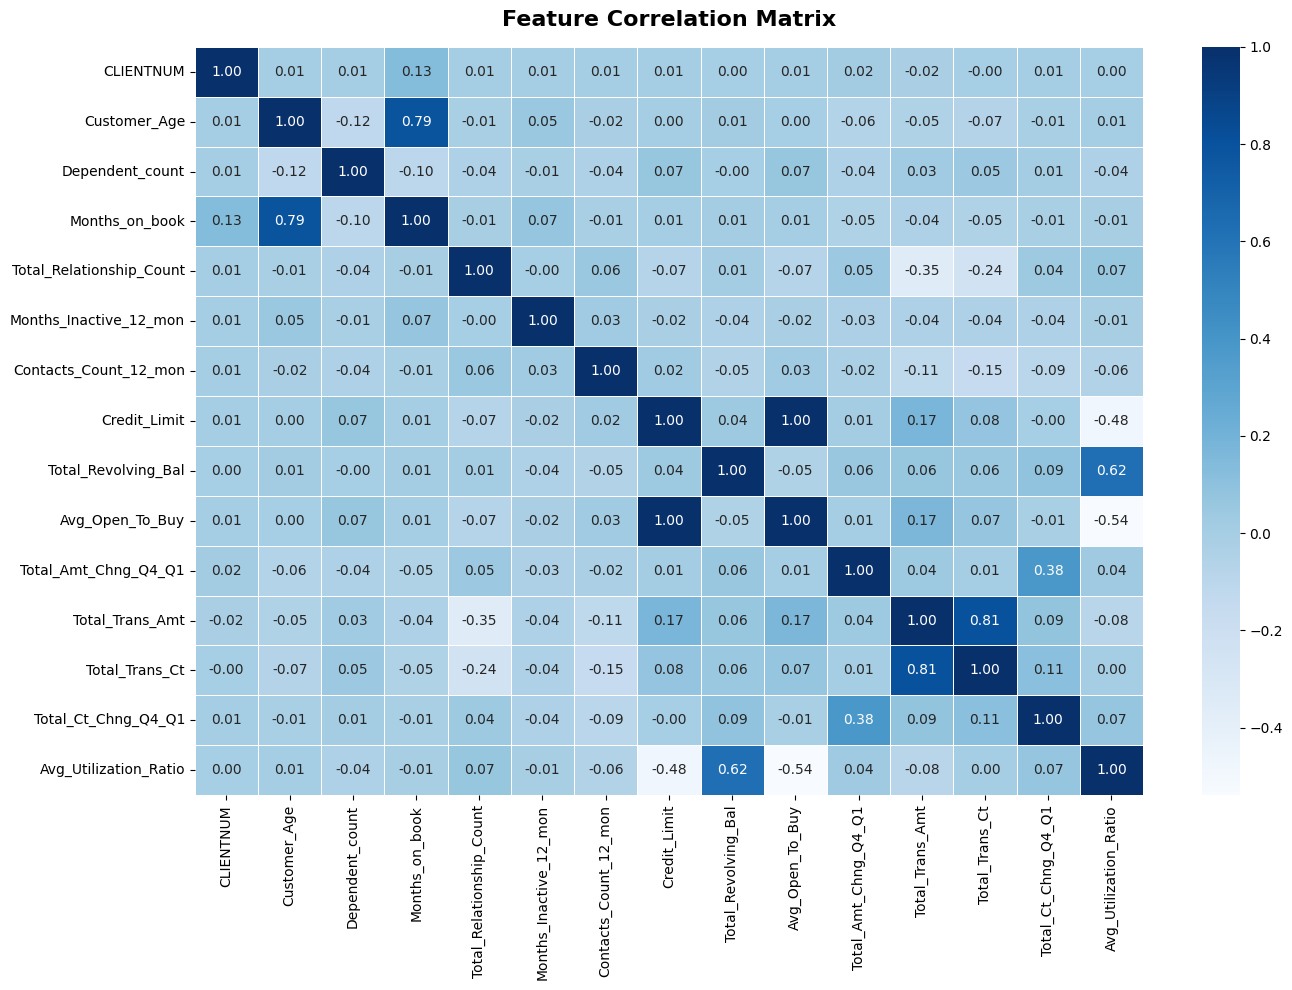

In [10]:
# ── Plot 7: Correlation heatmap — all numeric features ────────────────
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
fig7, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [11]:
# ── Plot 8: Bar chart — Contacts_Count_12_mon vs churn rate ───────────
q8 = pd.read_sql_query("""
    SELECT Contacts_Count_12_mon,
           ROUND(100.0*SUM(CASE WHEN Attrition_Flag='Attrited Customer'
                 THEN 1 ELSE 0 END)/COUNT(*), 2) as churn_pct
    FROM customers GROUP BY Contacts_Count_12_mon ORDER BY Contacts_Count_12_mon
""", con)
fig8 = px.bar(
    q8, x='Contacts_Count_12_mon', y='churn_pct',
    title='Churn Rate by Number of Contacts in Last 12 Months',
    template='plotly_white',
    text='churn_pct'
)
fig8.update_traces(marker_color='#006FCF', texttemplate='%{text}%', textposition='outside')
fig8.update_layout(
    xaxis_title='Contacts Count (12 mon)',
    yaxis_title='Churn Rate (%)',
    xaxis=dict(dtick=1)
)
fig8.show()

In [12]:
# ── Save cleaned data ──────────────────────────────────────────────────
df_clean = df.copy()
df_clean['is_attrited'] = (df_clean['Attrition_Flag'] == 'Attrited Customer').astype(int)
df_clean.to_csv('../../data/processed/customer_clean.csv', index=False)
print(f"Saved: data/processed/customer_clean.csv — shape {df_clean.shape}")

con.close()

Saved: data/processed/customer_clean.csv — shape (10127, 22)
